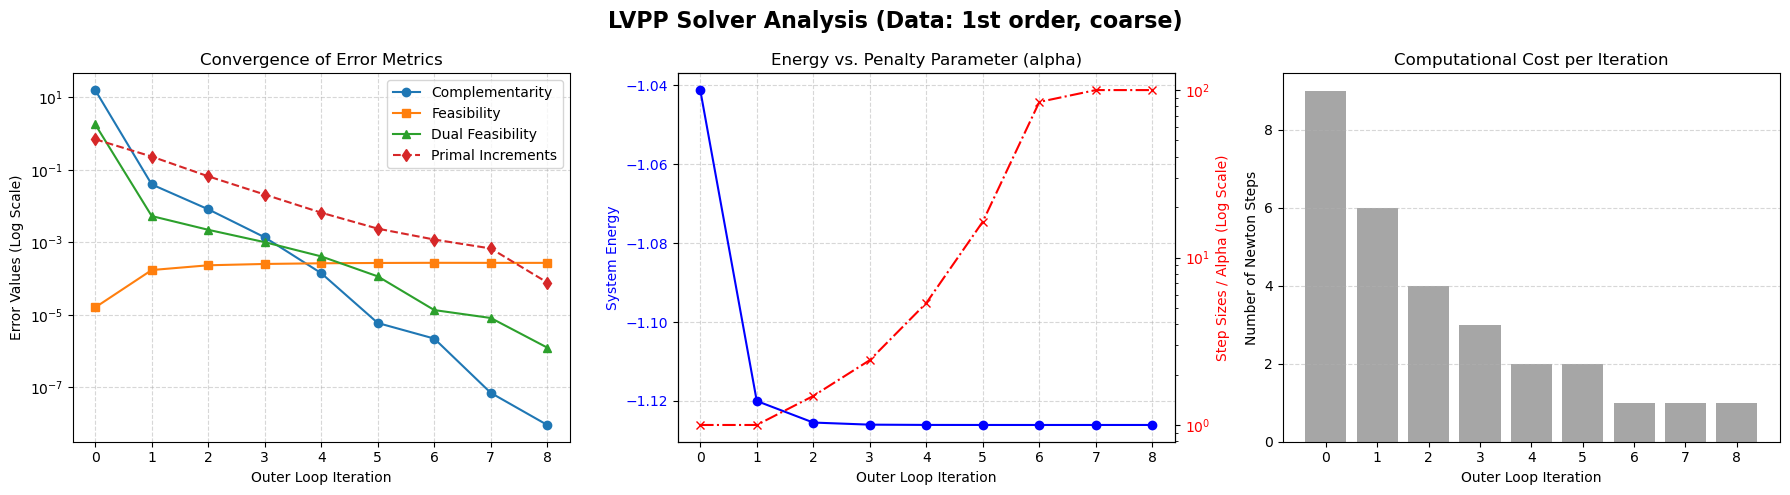

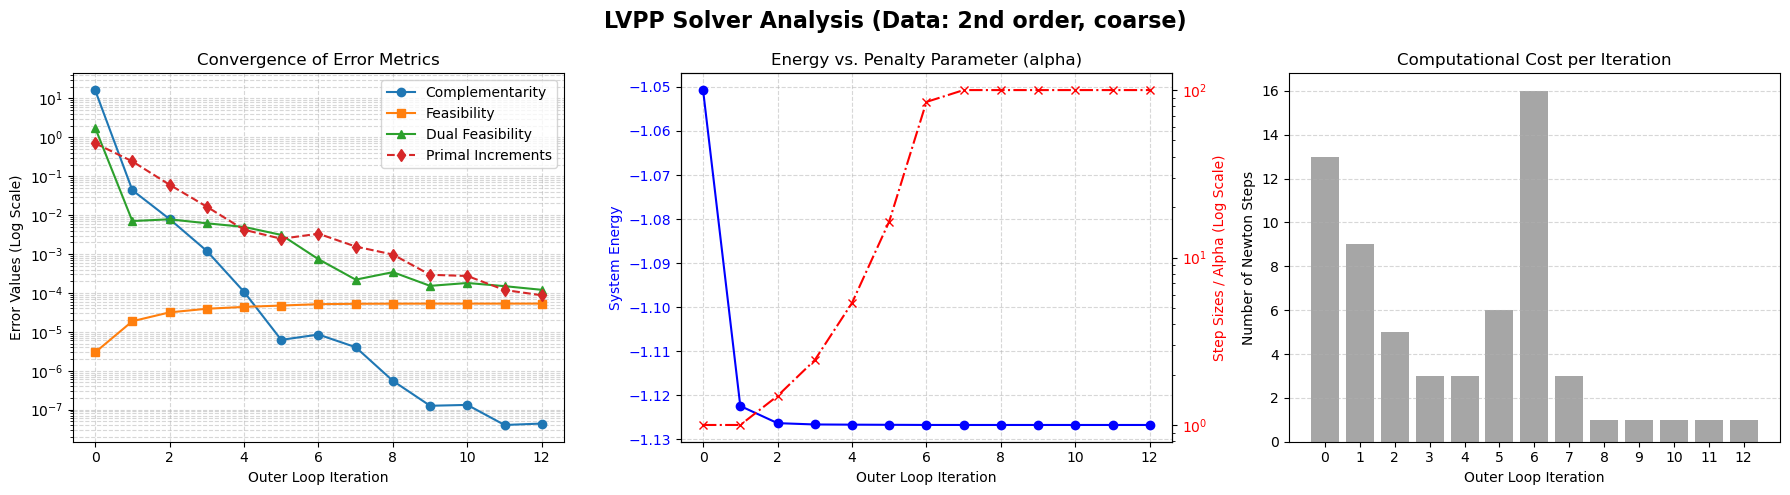

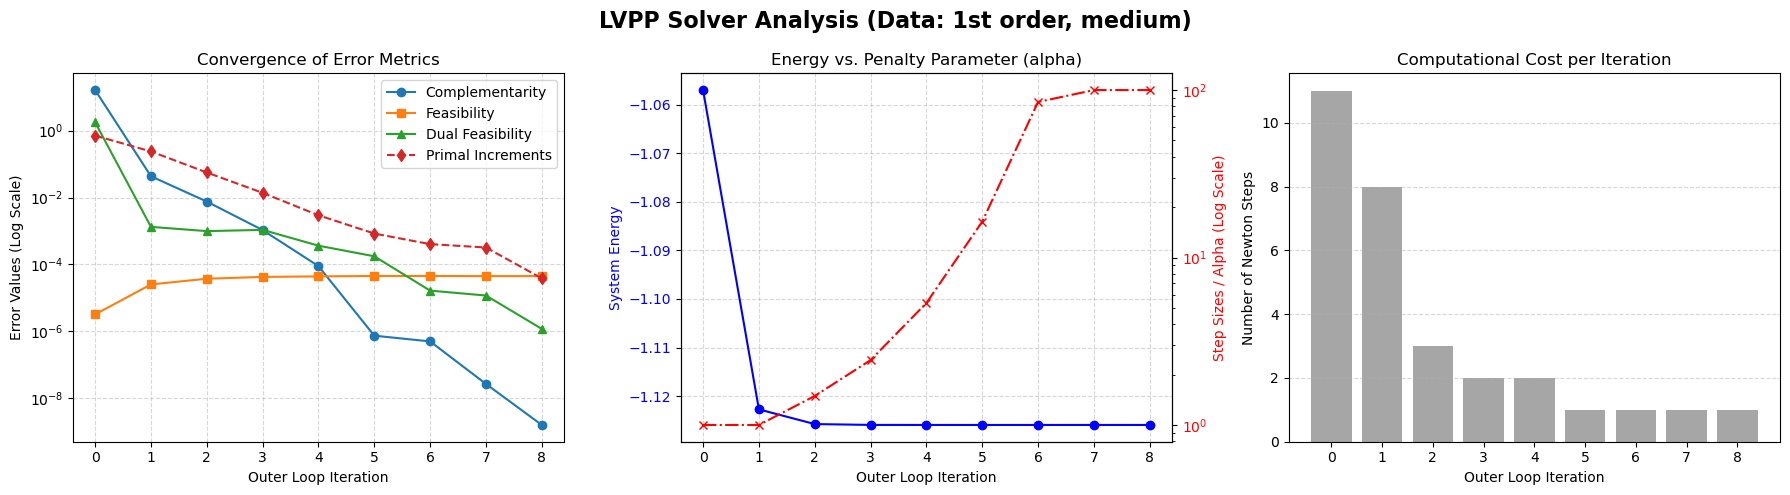

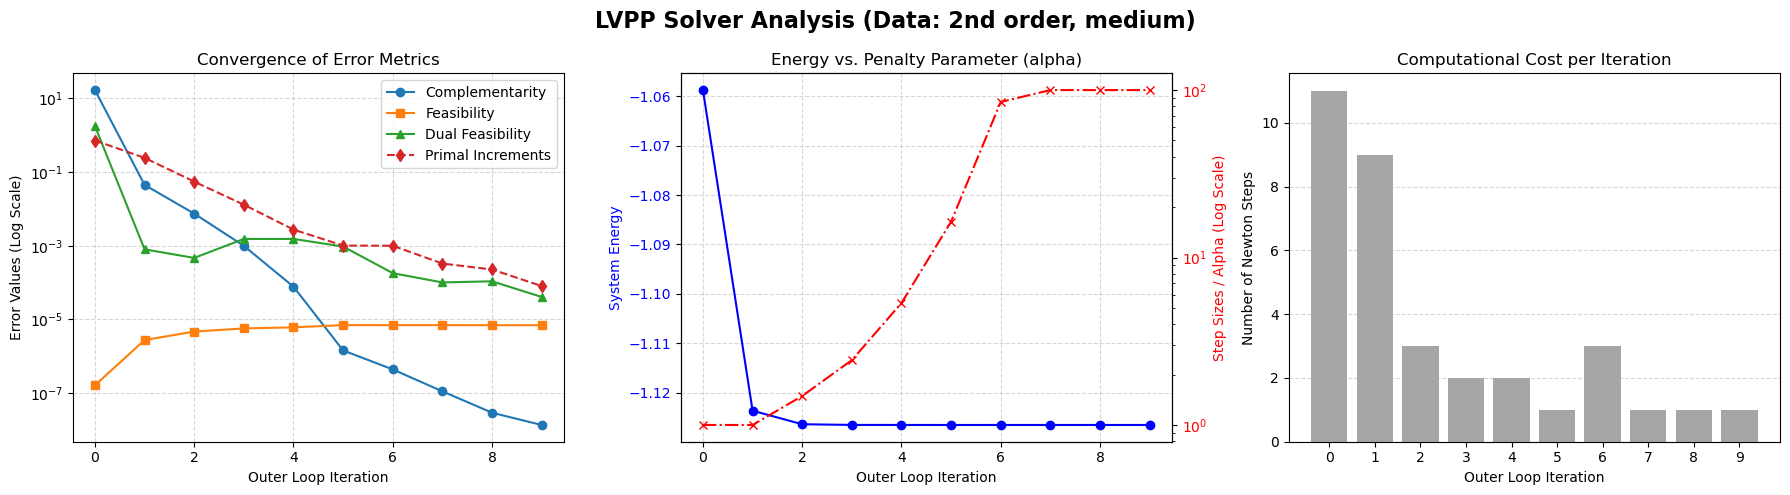

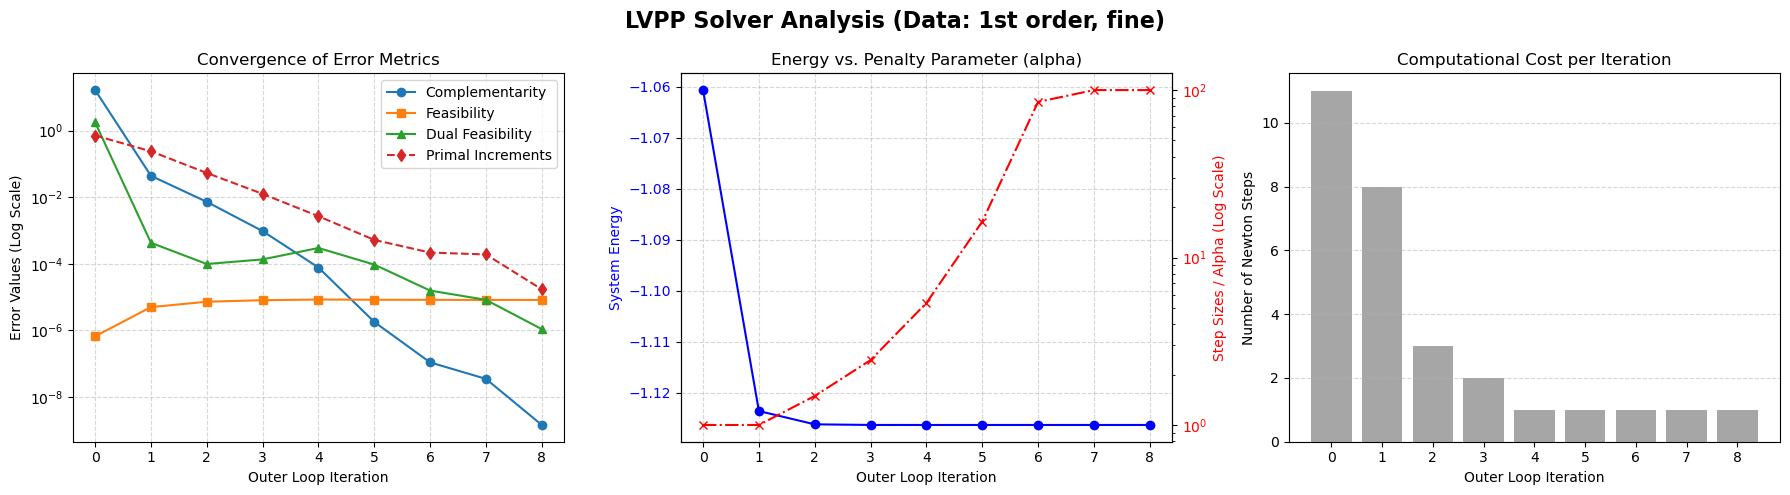

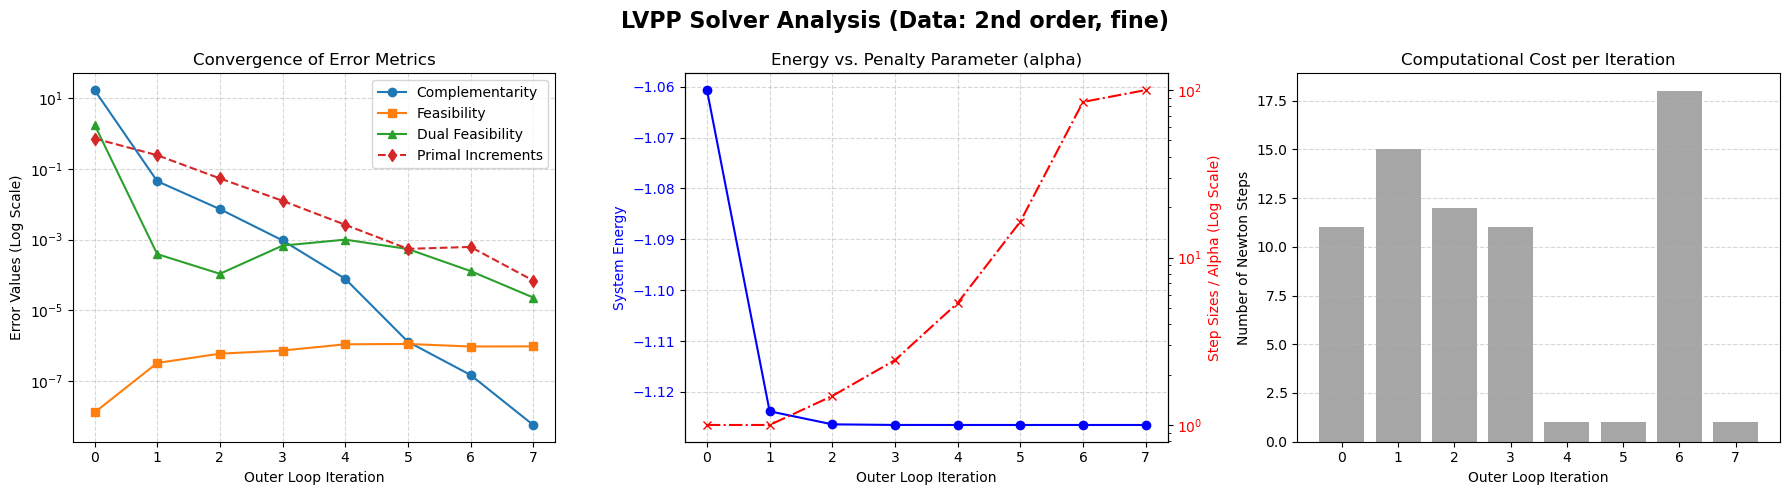

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기 (파일명은 실제 상황에 맞게 수정)
file_path = ["example_polyorder1_1578.csv", 
            "example_polyorder2_6183.csv", 
            "example_polyorder1_6183.csv",
            "example_polyorder2_24477.csv",
            "example_polyorder1_24477.csv",
            "example_polyorder2_97401.csv"
            ]
name = ["1st order, coarse",
        "2nd order, coarse",
        "1st order, medium",
        "2nd order, medium",
        "1st order, fine",
        "2nd order, fine"
        ]
for i in range(len(file_path)):
    try:
        df = pd.read_csv(file_path[i])
    except FileNotFoundError:
        print(f"Error: {file_path[i]} 파일을 찾을 수 없습니다.")
        exit()

    # 2. 그래프 그리기 세팅 (1행 3열)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"LVPP Solver Analysis (Data: {name[i]})", fontsize=16, fontweight='bold')

    # --- [그래프 1] 오차 지표들의 수렴 추이 (Log Scale) ---
    ax1 = axes[0]
    ax1.plot(df.index, df['Complementarity'], marker='o', label='Complementarity')
    ax1.plot(df.index, df['Feasibility'], marker='s', label='Feasibility')
    ax1.plot(df.index, df['Dual Feasibility'], marker='^', label='Dual Feasibility')
    ax1.plot(df.index, df['Primal increments'], marker='d', linestyle='--', label='Primal Increments')
    ax1.set_yscale('log')
    ax1.set_xlabel('Outer Loop Iteration')
    ax1.set_ylabel('Error Values (Log Scale)')
    ax1.set_title('Convergence of Error Metrics')
    ax1.grid(True, which="both", ls="--", alpha=0.5)
    ax1.legend()

    # --- [그래프 2] 페널티 파라미터(alpha)와 에너지의 관계 (이중 Y축) ---
    ax2 = axes[1]
    ax2.plot(df.index, df['Energy'], color='b', marker='o', label='Energy')
    ax2.set_xlabel('Outer Loop Iteration')
    ax2.set_ylabel('System Energy', color='b')
    ax2.tick_params(axis='y', labelcolor='b')

    ax2_twin = ax2.twinx()
    ax2_twin.plot(df.index, df['Step sizes'], color='r', marker='x', linestyle='-.', label='Step Sizes (alpha)')
    ax2_twin.set_yscale('log')
    ax2_twin.set_ylabel('Step Sizes / Alpha (Log Scale)', color='r')
    ax2_twin.tick_params(axis='y', labelcolor='r')
    ax2.set_title('Energy vs. Penalty Parameter (alpha)')
    ax2.grid(True, ls="--", alpha=0.5)

    # --- [그래프 3] 연산 비용 (Newton Steps) ---
    ax3 = axes[2]
    ax3.bar(df.index, df['Newton steps'], color='gray', alpha=0.7)
    ax3.set_xlabel('Outer Loop Iteration')
    ax3.set_ylabel('Number of Newton Steps')
    ax3.set_title('Computational Cost per Iteration')
    ax3.set_xticks(df.index)
    ax3.grid(axis='y', ls="--", alpha=0.5)

    # 3. 레이아웃 정리 및 출력
    plt.tight_layout()
    plt.show()